<a href="https://colab.research.google.com/github/marctnis/Projeto1ML/blob/main/Projeto_de_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo

In [ ]:
!pip install numba

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import classification_report, f1_score, balanced_accuracy_score, confusion_matrix


from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OrdinalEncoder,
    OneHotEncoder,
    TargetEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from imblearn.over_sampling import RandomOverSampler, SMOTENC
from imblearn.under_sampling import RandomUnderSampler

from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.preprocessing import PowerTransformer

#modelos
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import classification_report, f1_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_curve, auc, precision_recall_curve

In [ ]:
from ucimlrepo import fetch_ucirepo

adult_dataset = fetch_ucirepo(id=222)

df = adult_dataset.data.original


Definindo seed

In [ ]:
seed = 42

#Seção 1: O problema e os dados

Os dados que serão analisados nesse colab são do repositório de Machine Learning do UC Irvine. Abaixo encontra-se o link para acessá-lo:

https://archive.ics.uci.edu/dataset/222/bank+marketing

A variável alvo desses dados é a coluna y, que tem por objetivo prever se o cliente irá subscrever um depósito a prazo. Ou seja, se ele aceita a proposta do banco para fazer um investimento de renda fixa

Significado de cada atributo:

1. age: idade;
2. job: profissão do indivíduo;
3. marital: estado civil do indivíduo;
4. education: nível de educação do indivíduo;
5. default: indica se o cliente possui histórico de inadimplência com o banco;
6. balance: saldo bancário médio anual do cliente;
7. housing: financiamento imobiliário em andamento ou não;
8. loan: indica se o cliente possui um empréstimo pessoal ativo;
9. contact: tipo de comunicação de contato;
10. day_of_week: último dia de contato da semana;
11. month: mês do ano que teve o último contato;
12. duration: duração do último contato, em segundos;
13. campaign: número de contatos realizados durante esta campanha e para este cliente;
14. pdays: número de dias que se passaram desde que o cliente foi contatado pela última vez em uma campanha anterior;
15. previous: número de contatos realizados antes desta campanha e para este cliente;
16. poutcome: resultado da campanha de marketing anterior;

Esse conjunto de dados está licenciado sob uma licença Creative Commons Attribution 4.0 International (CC BY 4.0).

#Seção 2: Exploração

*dimensões, tipos, valores faltantes, balanceamento das classes, distribuições dos
atributos e as relações mais informativas com o alvo. A avaliação prioriza a pertinência e a interpretação das
análises, não a quantidade de gráficos.*

Nessa etapa será realizada a análise dos dados que possuímos para identificar o que poderá ser feito nas seções posteriores em relação a parte de limpeza e treinamento.

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


Por meio do df.info, vê-se a presença de muitas colunas categóricas. Veremos o tratamento na etapa de encoding.

Balance, saldo bancário médio anual, deverá ter uma normalização. Pelo df.head é perceptível a presença de outliers, mas vamos analisá-los melhor:

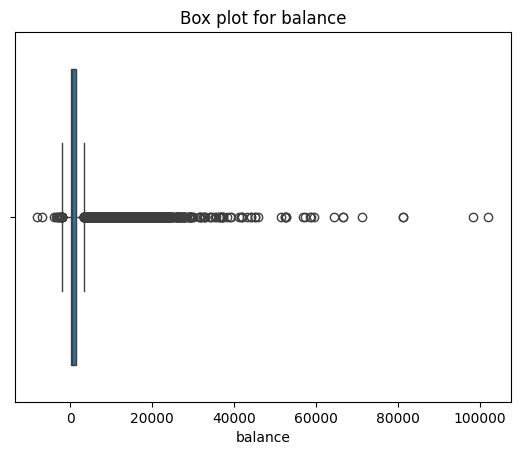

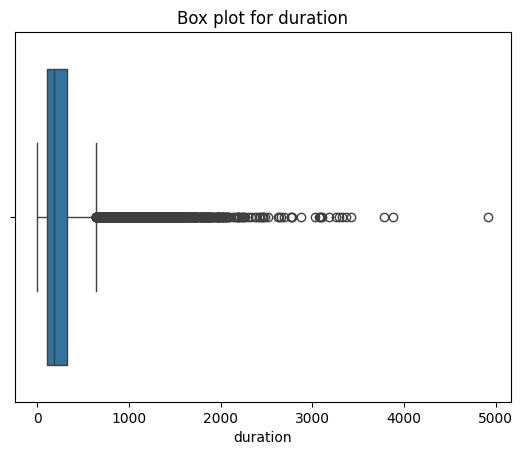

In [ ]:
sns.boxplot(x=df['balance'])
plt.title("Box plot for balance")
plt.show()

sns.boxplot(x=df['duration'])
plt.title("Box plot for duration")
plt.show()

Também há a presença de outliers em duration. Em relação ao primeiro boxplot: a presença de valores negativos não significa que seja ruído, pois é possível que alguém gastou mais dinheiro do que tinha disponível em saldo livre.

Como dito anteriormente, usaremos normalização em balance. Devido a presença de valores negativos, vamos adotar a técnica de Yeo-Johnson ou Signed Log.

Para duration podemos usar o Signed Log também, já que o RobustScaler apesar de desconsiderar os valores discrepantes

Verificando a presença de valores duplicados

In [ ]:
perc_duplicated = f'{df.duplicated().sum() * 100}%'
print(perc_duplicated)

0%


Verificando a presença de valores nulos

In [ ]:
df.isnull().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day_of_week,0


In [ ]:
df.shape

(45211, 17)

Com isso é perceptível que a quantidade de valores nulos em poutcome são quase a quantidade de linhas totais do dataset. É necessário analisar sua relação com o target para saber se faz sentido deixar essa feature ou se iremos preencher com algum dado.

Verificando o desbalanceamento das classes

In [ ]:
df['y'].value_counts() / len(df)

,count
y,
no,0.883015
yes,0.116985


Podemos perceber aqui que há em torno de 88.3% dos valores são da classe 'no', enquanto que 11.6% é da classe 'sim'. Há um desbalanceamento severo no dataset.

Analisando correlação entre as features numéricas.

In [ ]:
df_temp = df.copy()
df_temp['y_num'] = df_temp['y'].map({'no': 0, 'yes': 1})

numeric_df = df_temp.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr(method='spearman')


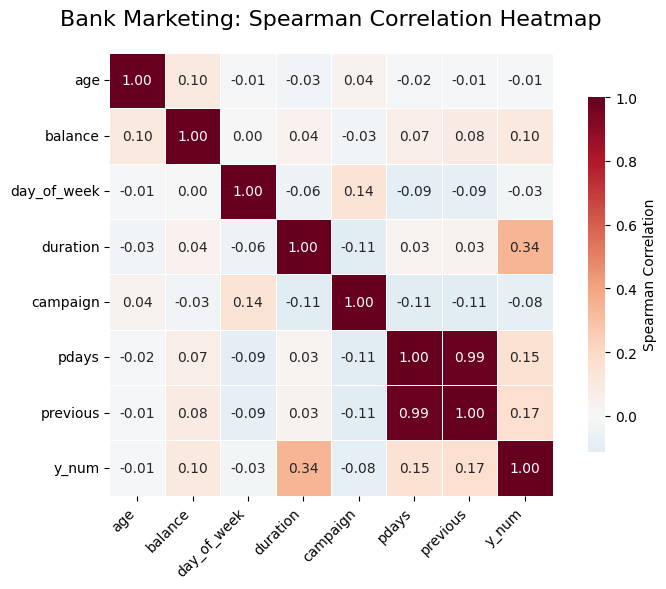

In [ ]:
fig = plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Spearman Correlation'})

plt.title('Bank Marketing: Spearman Correlation Heatmap',
          fontsize=16, pad=20)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


Esse heatmap nos mostra que pdays e previous possuem alta correlação. Faz sentido, pois pdays diz a quantidade de dias que se passaram desde a última vez que entraram em contato com o cliente e previous determina a quantidade de contatos realizados desde a últim campanha, é nítido aqui que se não houve ligações anteriores não será possível que tenham dias passados desde a última contatação. Da mesma forma, se não houveram dias anteriores desde a última contatação, é porque não teve uma quantidade de vezes que o cliente foi contatato.

Dá para tratar as duas colunas como uma só informação, devido a alta correlação. Entretanto é importante aqui analisar também que pdays ter -1 dias pode confundir modelos que treinam por distância.

Aqui percebemos também a correlação com o target que é baixa em todos os casos, apenas duration que possui um valor mais alto, mas como já discutido, ele representa data leakage e não deve ser usado como um preditor real.

Apesar de possuirem alta correlação, as colunas passam informações diferentes. Dois clientes que tiverem apenas 1 contatação desde a última campanha podem ter dias diferentes em relação ao tempo da campanha anterior. Um pode ser 10 dias e o outro pode ser 50.

In [ ]:
df[df['previous'] > 0][['pdays', 'previous']].corr(method='spearman')

,pdays,previous
pdays,1.000000,-0.101273
previous,-0.101273,1.000000


Esse resultado nos mostra que na verdade há pouca relação entre pdays e previous. A relação anterior se deu por conta da quantidade de valores que apareceram referentes aos números analisados.

In [ ]:
#Precisamos confimar se em todos os casos que pdays é -1 previous também será 0
(df['pdays'] == -1).equals(df['previous'] == 0)

True

Isso significa que em todos os casos que pdays é -1 previous será 0. Podemos considerar então apenas a informação de previous = 0 para esse caso.

In [ ]:
df['pdays_validos'] = df['pdays'].replace(-1, np.nan)

Como pdays_validos já mostra os dias validos, podemos descartar a coluna pdays

In [ ]:
df.drop('pdays', axis=1, inplace=True)

Análise de relação das features com o target.

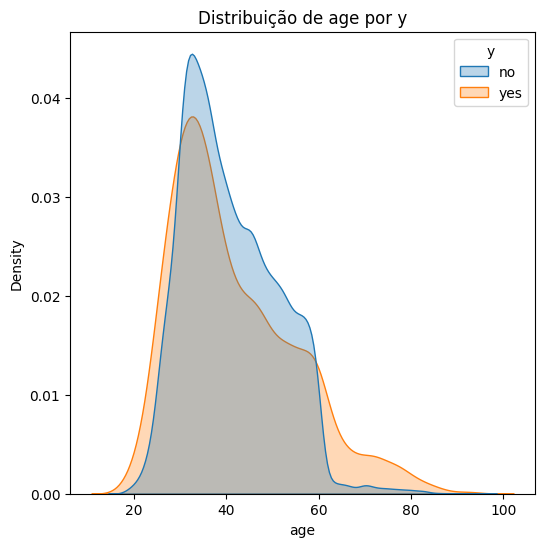

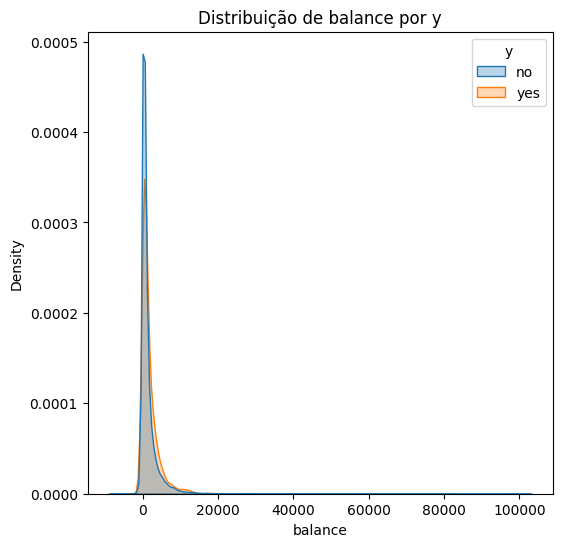

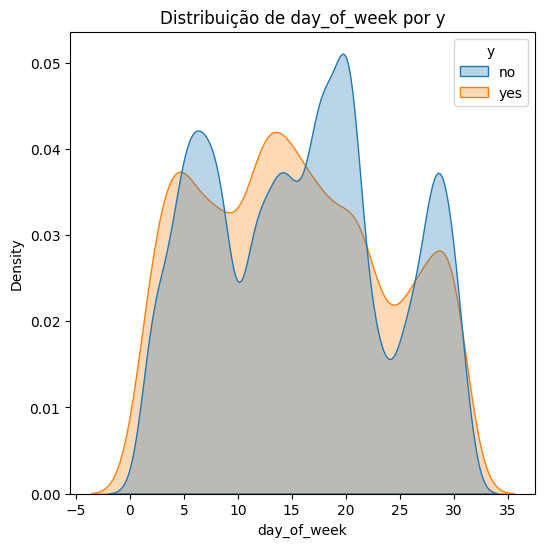

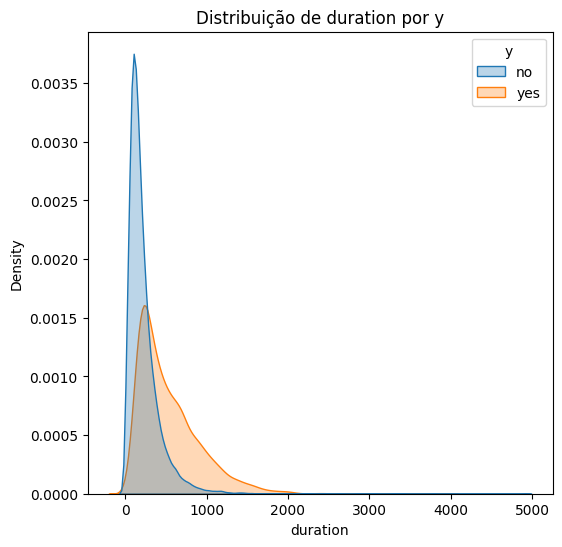

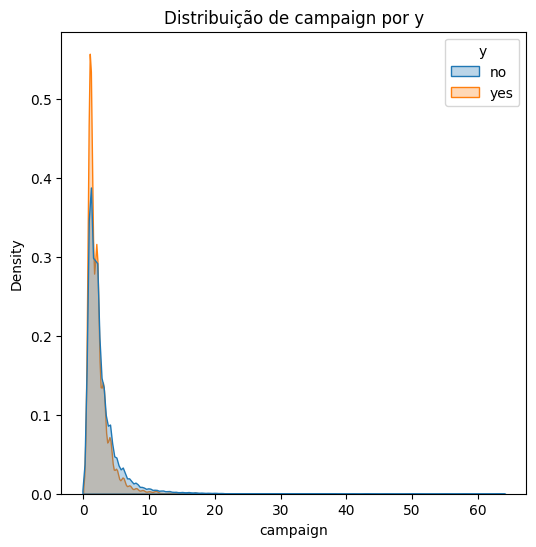

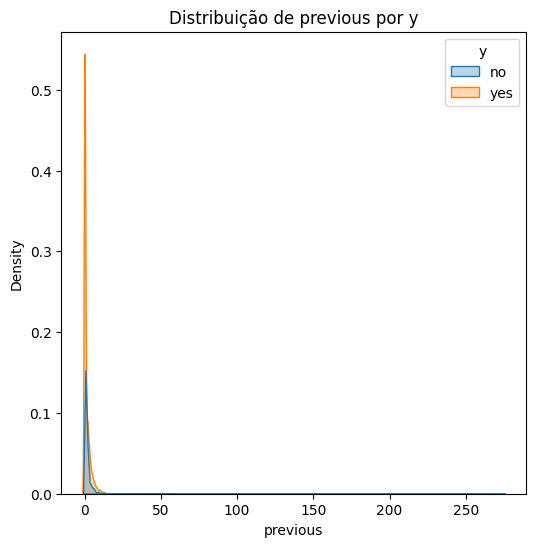

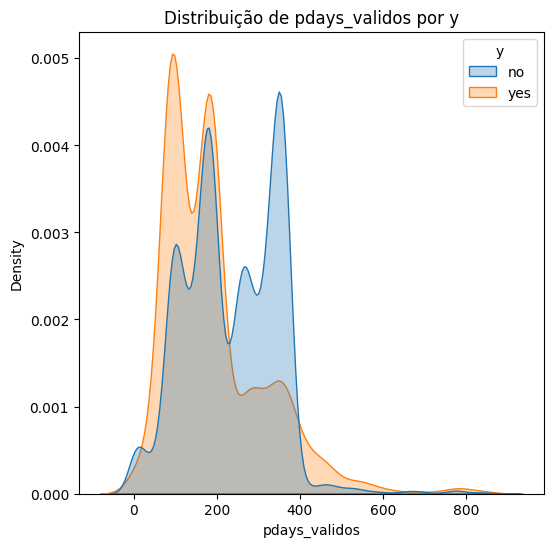

In [ ]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

for col in numerical_columns:
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    sns.kdeplot(data=df, x=col, hue="y", common_norm=False, fill=True, alpha=0.3)
    plt.title(f'Distribuição de {col} por y')
    plt.show()

Analisando os picos de cada gráfico, percebemos que duration tem alta relação com o target. Isso na verdade foi dito pelo próprio site que disponibiliza o dataset, pois a duração de uma ligação só pode ser percebida depois que ela acaba, porém, depois que a ligação acaba é que temos o nosso target. Por isso duration tem alta relação.

Como a moda de cada classe está distante uma da outra, dizemos que a relação é alta com o target, pois conforme eu vario o X, eu me aproximo de uma classe e me distancio da outra. O contrário também é válido. Já se as modas fossem muito próximas, as classes ficariam indistinguíveis.

Analisando agora a relação das features categóricas com o target.

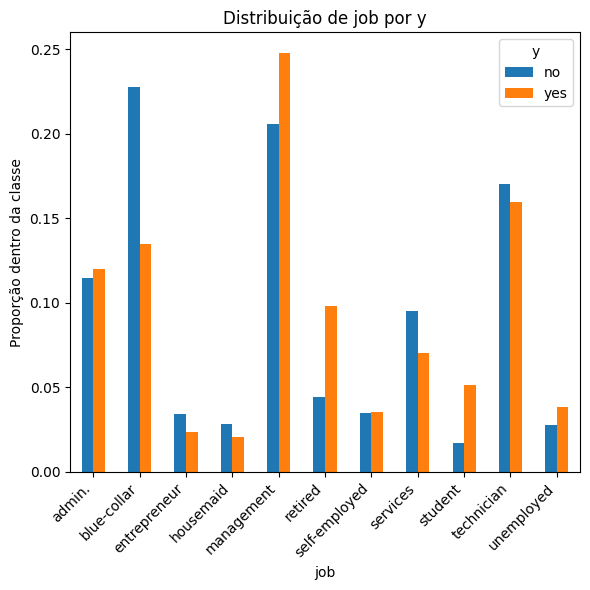

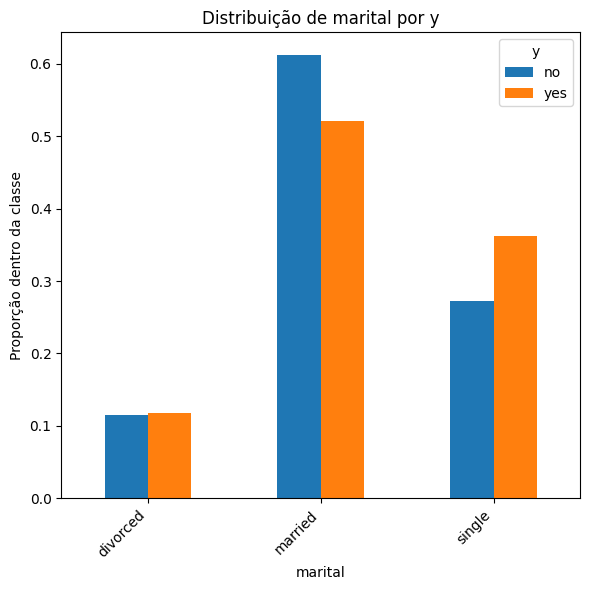

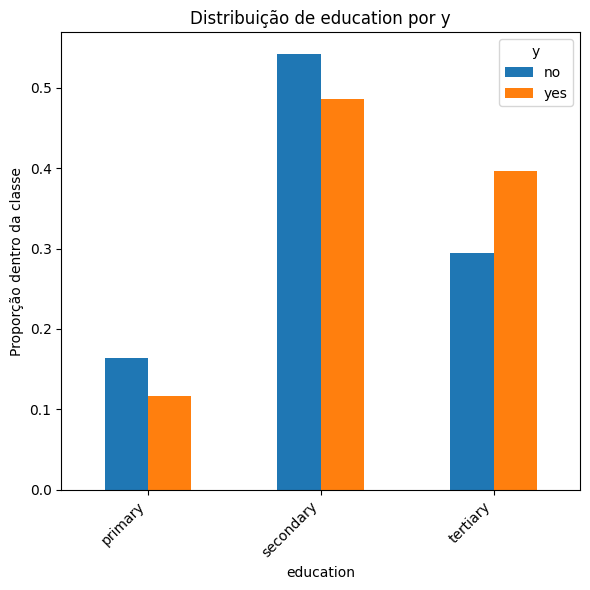

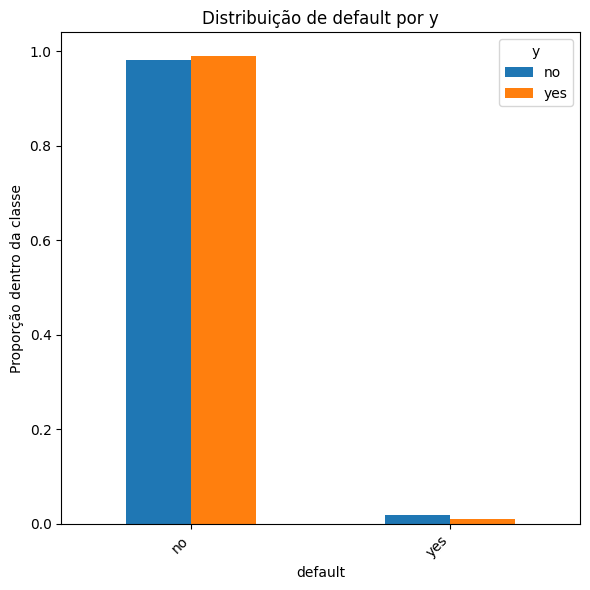

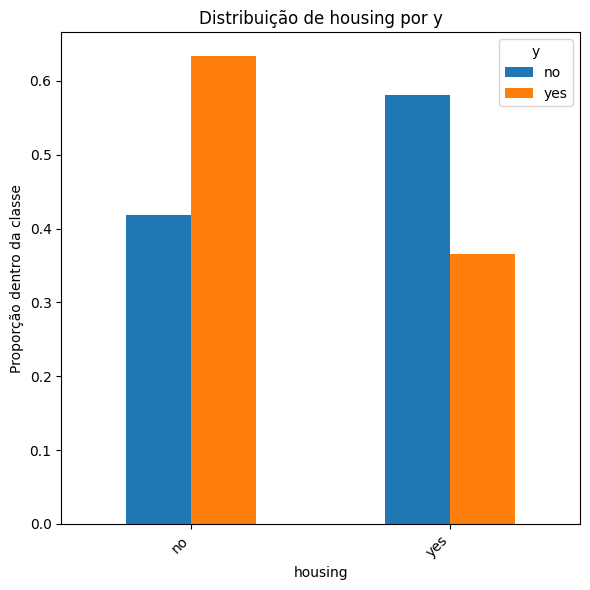

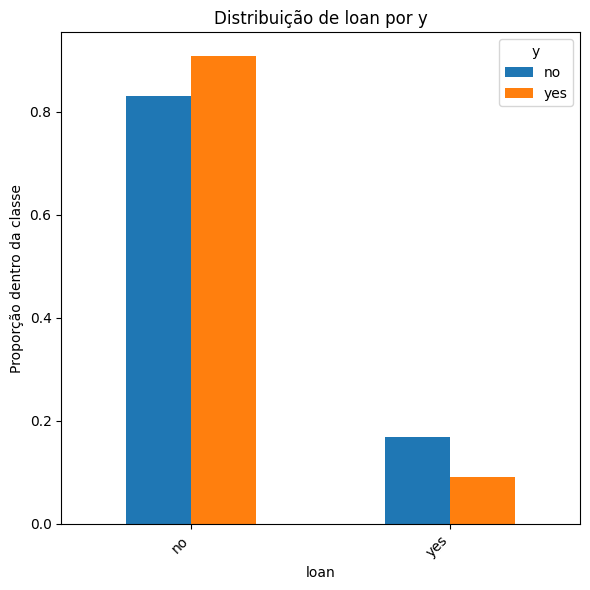

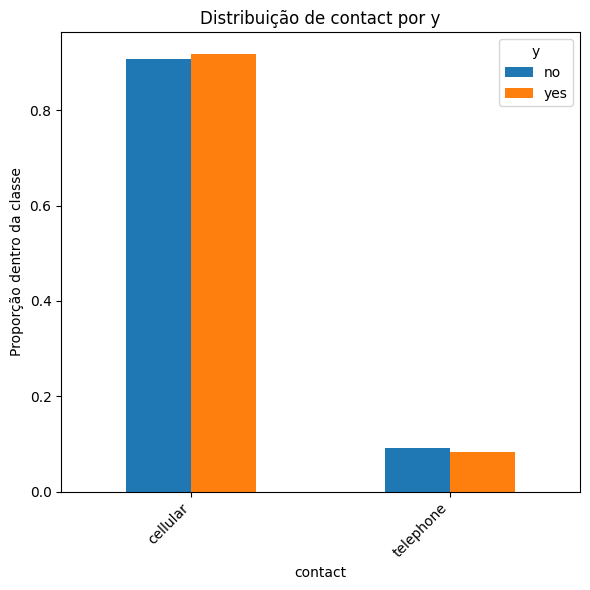

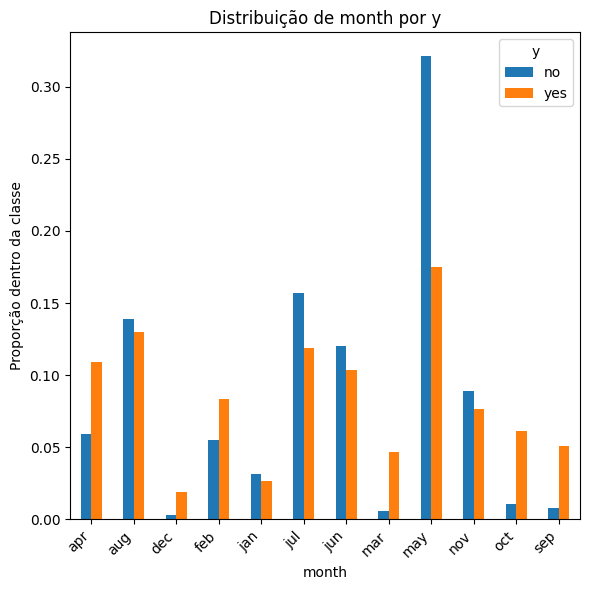

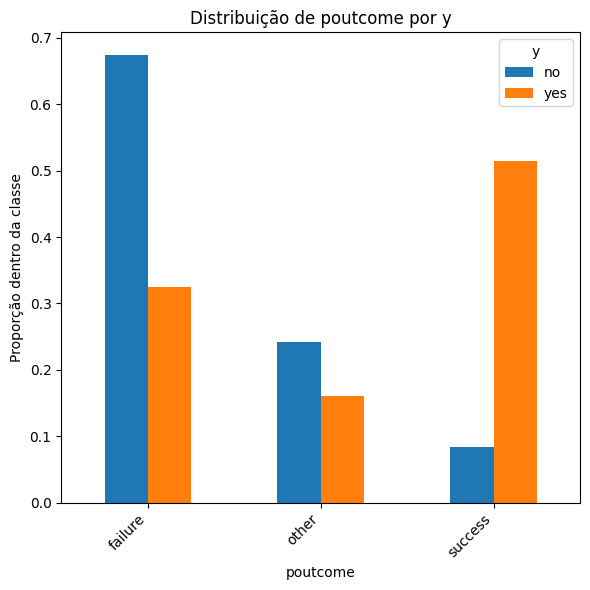

In [ ]:
categorical_columns = df.select_dtypes(include='object').columns.tolist()
categorical_columns.remove('y')

for col in categorical_columns:
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))

    ct = pd.crosstab(df[col], df['y'], normalize='columns')
    ct.plot(kind='bar', ax=ax)
    plt.title(f'Distribuição de {col} por y')
    plt.ylabel('Proporção dentro da classe')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='y')
    plt.tight_layout()
    plt.show()

A quantidade de valores faltantes em contacts é considerável, como vimos anteriormente. Possui baixa relação com o target. Isso faz com que adicionar uma nova categoria para desconhecido não tenha muitos problemas.

Apesar de poutcome apresentar quantidade muito alta de valores faltantes, como possui muita relação com o target o mais adequado seria criar uma nova classe para os valores faltantes: desconhecido.

Essa relação com o target acontece porque a proporção de 'yes' varia significativamente entre as categorias de poutcome - clientes em campanha anterior convertem muito mais. Por isso, o mais adequado é criar uma nova categoria "desconhecido" para os faltantes, preservando essa informação relevante em vez de descartá-la.

Através desses gráficos percebemos que:

Clientes solteiros geralmente apresentam mais respostas sim;

Clientes que possuem nível maior de escolaridade apresentam mais respostas sim;

Clientes que não possuem financiamento imobiliário em andamento apresentam mais respostas sim;

Clientes que não possuem um empréstimo pessoal ativo apresentam mais respostas sim

Clientes que tiveram sucesso no resultado da campanha anterior apresentam mais respostas sim;


#Seção 3: Preparação

*limpeza, tratamento de faltantes, codificação de categóricos e a divisão em TREINO,
VALIDAÇÃO e TESTE (com semente fixa e proporções justificadas). O conjunto de teste é tocado uma
única vez, na Seção 5.*

###Split

Como dito em sala, o split será feito dividindo inicialmente 70 para treino e 30 para teste, mas esses 30 serão divididos entre 15 e 15, para validação e teste, de fato.

In [ ]:
df_train, df_temp = train_test_split(df, test_size=0.3, stratify=df['y'], random_state=seed)
df_val, df_test = train_test_split(df_temp, test_size=0.5, stratify=df_temp['y'], random_state=seed)

In [ ]:
# Imputar com a mediana calculada SÓ no treino
mediana_pdays = df_train['pdays_validos'].median()

for dataset in [df_train, df_val, df_test]:
    dataset['pdays_validos'] = dataset['pdays_validos'].fillna(mediana_pdays)

###Tratamento de valores faltantes

A quantidade de valores faltantes em job não é considerável quando comparado a quantidade de pessoas que fazem parte do dataset, então usar moda não há muito problema, mas criar uma categoria de desconhecido não gera grande impacto também.

In [ ]:
columns = ['poutcome', 'contact', 'education', 'job']

for dataset in [df_train, df_val, df_test]:
    dataset[columns] = dataset[columns].fillna('unknown')


###Normalização

Ao analisar os dados nos boxplots, percebemos que usar transformação log10 não faz sentido em balance e duration, pois balance contém valores negativos, então o logarítimo para ele não funciona. O log10 para valores nulos não existe, então o mais recomendado para o duration seria log(x+1).

Em particular, para o balance pensamos em utilizar o Signed Log, que nada mais é a união de 2 funções do numpy, de forma que np.sign pega o sinal do valor analisado e log1p coloca o valor em escala logarítmica. A junção das duas faz com que o sinal seja preservado no final.

In [ ]:
for dataset in [df_train, df_val, df_test]:
  dataset['balance_signed_log'] = np.sign(dataset['balance']) * np.log1p(np.abs(dataset['balance']))
  dataset['duration_log'] = np.log1p(dataset['duration'])

In [ ]:
df_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,previous,poutcome,y,pdays_validos,balance_signed_log,duration_log
13382,31,services,married,secondary,no,1,yes,no,cellular,9,jul,82,1,0,unknown,no,195.0,0.693147,4.418841
32641,35,services,married,secondary,no,195,yes,no,cellular,17,apr,203,1,0,unknown,no,195.0,5.278115,5.318120
3991,24,blue-collar,single,secondary,no,77,yes,no,unknown,16,may,236,2,0,unknown,no,195.0,4.356709,5.468060
8068,35,blue-collar,married,secondary,no,80,yes,yes,unknown,2,jun,579,2,0,unknown,no,195.0,4.394449,6.363028
27484,37,services,single,secondary,no,105,no,yes,cellular,21,nov,197,2,4,failure,no,157.0,4.663439,5.288267


###Encoding

In [ ]:
y_train_num = df_train['y'].map({'no': 0, 'yes': 1})

education_map = {'primary': 0, 'secondary': 1, 'tertiary': 2, 'unknown': 3}

for dataset in [df_train, df_val, df_test]:
    dataset['education'] = dataset['education'].replace(education_map)

target = TargetEncoder()
lista_target = ['job', 'marital', 'default', 'housing', "loan", 'contact', 'month', 'poutcome']

df_train[lista_target] = target.fit_transform(df_train[lista_target], y_train_num)
df_val[lista_target]   = target.transform(df_val[lista_target])
df_test[lista_target]  = target.transform(df_test[lista_target])

/tmp/ipykernel_8820/1044572830.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset['education'] = dataset['education'].replace(education_map)


In [ ]:
df_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,previous,poutcome,y,pdays_validos,balance_signed_log,duration_log
13382,31,0.089736,0.098174,1,0.118000,1,0.077437,0.125940,0.149781,9,0.095487,82,1,0,0.093186,no,195.0,0.693147,4.418841
32641,35,0.089736,0.098174,1,0.118000,195,0.077437,0.125940,0.149781,17,0.194391,203,1,0,0.093186,no,195.0,5.278115,5.318120
3991,24,0.071973,0.153358,1,0.118106,77,0.078091,0.126194,0.041751,16,0.066886,236,2,0,0.092676,no,195.0,4.356709,5.468060
8068,35,0.071973,0.097985,1,0.118106,80,0.078091,0.068770,0.041751,2,0.106429,579,2,0,0.092676,no,195.0,4.394449,6.363028
27484,37,0.096111,0.153358,1,0.118106,105,0.165404,0.068770,0.148186,21,0.098331,197,2,4,0.122257,no,157.0,4.663439,5.288267


###Balanceamento dos dados

Aqui vamos escolher o método de balanceamento que se sair melhor nos resultados

In [ ]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
cat_indices = [df_train.drop(columns=['y']).columns.get_loc(col) for col in cat_cols]

In [ ]:
metodos_balanceamento = {
    'none': 'passthrough',
    'random_over': RandomOverSampler(random_state=seed),
    'random_under': RandomUnderSampler(random_state=seed),
    'smotenc': SMOTENC(categorical_features=cat_indices, random_state=seed)
}

Declarando o LVQ

In [ ]:
def treinar_lvq(X, y, por_classe, epocas=30, alfa0=0.30, semente=0):
    r = np.random.RandomState(semente)
    prot, rot = [], []
    for c in np.unique(y):
        idx = r.choice(np.where(y == c)[0], size=por_classe, replace=False)
        prot.append(X[idx].copy()); rot += [c] * por_classe
    W = np.vstack(prot); rotW = np.array(rot)
    for ep in range(1, epocas + 1):
        alfa = alfa0 * (1 - ep / (epocas + 1))
        for i in r.permutation(len(X)):
            d = ((W - X[i]) ** 2).sum(axis=1)
            v = int(np.argmin(d))
            if rotW[v] == y[i]:
                W[v] = W[v] + alfa * (X[i] - W[v])   # aproxima
            else:
                W[v] = W[v] - alfa * (X[i] - W[v])   # afasta
    return W, rotW

class LVQ(BaseEstimator, ClassifierMixin):
    def __init__(self, por_classe=10, epocas=30, alfa0=0.30, semente=0):
        self.por_classe = por_classe
        self.epocas = epocas
        self.alfa0 = alfa0
        self.semente = semente

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.W, self.rotW = treinar_lvq(
            X, y,
            por_classe=self.por_classe,
            epocas=self.epocas,
            alfa0=self.alfa0,
            semente=self.semente
        )
        return self

    def predict(self, Xq):
        Xq = np.asarray(Xq)
        d = ((Xq[:, None, :] - self.W[None, :, :]) ** 2).sum(axis=2)
        return self.rotW[np.argmin(d, axis=1)]

    def score(self, Xq, yq):
        return float((self.predict(Xq) == np.asarray(yq)).mean())

In [ ]:
modelos = {'knn': KNeighborsClassifier(), 'decision_tree': DecisionTreeClassifier(), 'lvq': LVQ(por_classe=10, epocas=30, alfa0=0.3, semente=seed)}

In [ ]:
X_train = df_train.drop(columns=['y'])
X_val = df_val.drop(columns=['y'])
X_test = df_test.drop(columns=['y'])

y_val = df_val['y'].map({'no': 0, 'yes': 1})
y_test = df_test['y'].map({'no': 0, 'yes': 1})

resultados = []

for model_name, modelo in modelos.items():
    for key, value in metodos_balanceamento.items():
        pipeline = ImbPipeline([
            ('balancer', value),
            ('model', modelo)
        ])
        pipeline.fit(X_train, y_train_num)
        score = pipeline.score(X_val, y_val)
        resultados.append({'modelo': model_name, 'balanceamento': key, 'score': score})

/usr/local/lib/python3.13/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline 

#Seção 4: Baselines com busca de hiperparâmetros


Nessa seção partimos dos resultados da Seção 3 (baselines sem ajuste de hiperparâmetros, testados com diferentes estratégias de balanceamento). Para cada modelo (KNN, Árvore de Decisão e LVQ), escolhemos a estratégia de balanceamento que teve melhor desempenho na validação e, em seguida, fazemos uma busca de hiperparâmetros (GridSearchCV) com validação cruzada usando apenas o conjunto de TREINO. O conjunto de teste continua intocado, sendo usado somente na Seção 5.

In [ ]:
df_resultados = pd.DataFrame(resultados)
print(df_resultados.pivot(index='modelo', columns='balanceamento', values='score'))

melhor_balanceamento_por_modelo = (
    df_resultados
    .loc[df_resultados.groupby('modelo')['score'].idxmax()]
    .set_index('modelo')['balanceamento']
)
melhor_balanceamento_por_modelo

balanceamento      none  random_over  random_under   smotenc
modelo                                                      
decision_tree  0.879387     0.873931      0.806252  0.848127
knn            0.883958     0.793571      0.760395  0.780596
lvq            0.887054     0.117075      0.740784  0.117075


,balanceamento
modelo,
decision_tree,none
knn,none
lvq,none


###Grades de hiperparâmetros

- **KNN**: número de vizinhos, tipo de peso (uniforme ou por distância) e a métrica de distância (Manhattan ou Euclidiana);
- **Árvore de Decisão**: profundidade máxima, número mínimo de amostras para dividir um nó, número mínimo de amostras por folha e critério de divisão;
- **LVQ**: número de prototypes por classe, número de épocas e taxa de aprendizado inicial.

In [ ]:
param_grids = {
    'knn': {
        'model__n_neighbors': [3, 5, 7, 9, 11, 15],
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2]
    },
    'decision_tree': {
        'model__max_depth': [3, 5, 8, 12, None],
        'model__min_samples_split': [2, 5, 10, 20],
        'model__min_samples_leaf': [1, 2, 5, 10],
        'model__criterion': ['gini', 'entropy']
    },
    'lvq': {
        'model__por_classe': [5, 10, 20, 30],
        'model__epocas': [10, 30, 50],
        'model__alfa0': [0.1, 0.3, 0.5]
    }
}

In [ ]:
from numba import njit

@njit(cache=True)
def _atualizar_epoca(X, y, perm, W, rotW, alfa):
    n_prot, n_feat = W.shape
    for idx in range(perm.shape[0]):
        i = perm[idx]
        melhor_dist = 1e18
        v = 0
        for k in range(n_prot):
            dist = 0.0
            for f in range(n_feat):
                diff = W[k, f] - X[i, f]
                dist += diff * diff
            if dist < melhor_dist:
                melhor_dist = dist
                v = k
        if rotW[v] == y[i]:
            for f in range(n_feat):
                W[v, f] = W[v, f] + alfa * (X[i, f] - W[v, f])
        else:
            for f in range(n_feat):
                W[v, f] = W[v, f] - alfa * (X[i, f] - W[v, f])
    return W


def _treinar_lvq_rapido(X, y, por_classe, epocas=30, alfa0=0.30, semente=0):
    X = np.ascontiguousarray(X, dtype=np.float64)
    y = np.ascontiguousarray(y)
    r = np.random.RandomState(semente)

    prot, rot = [], []
    for c in np.unique(y):
        idx = r.choice(np.where(y == c)[0], size=por_classe, replace=False)
        prot.append(X[idx].copy())
        rot += [c] * por_classe

    W = np.ascontiguousarray(np.vstack(prot), dtype=np.float64)
    rotW = np.ascontiguousarray(np.array(rot))

    for ep in range(1, epocas + 1):
        alfa = alfa0 * (1 - ep / (epocas + 1))
        perm = r.permutation(len(X)).astype(np.int64)
        W = _atualizar_epoca(X, y, perm, W, rotW, alfa)

    return W, rotW


class LVQRapido(LVQ):
    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.W, self.rotW = _treinar_lvq_rapido(
            X, y,
            por_classe=self.por_classe,
            epocas=self.epocas,
            alfa0=self.alfa0,
            semente=self.semente
        )
        return self


modelos_busca = dict(modelos)
modelos_busca['lvq'] = LVQRapido(por_classe=10, epocas=30, alfa0=0.3, semente=seed)

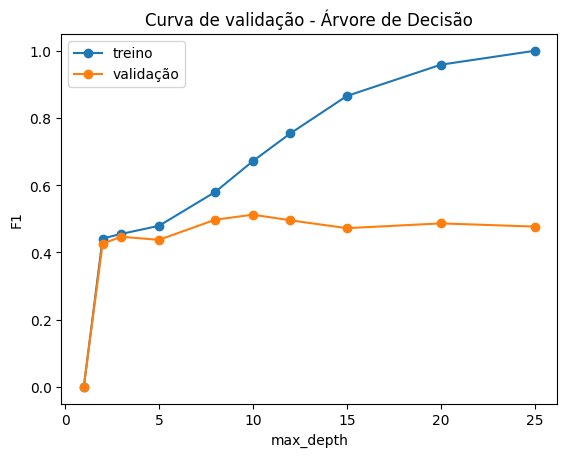

In [ ]:
depths = [1, 2, 3, 5, 8, 10, 12, 15, 20, None]
f1_treino, f1_valid = [], []

for d in depths:
    modelo = DecisionTreeClassifier(max_depth=d, random_state=seed)
    modelo.fit(X_train, y_train_num)
    f1_treino.append(f1_score(y_train_num, modelo.predict(X_train)))
    f1_valid.append(f1_score(y_val, modelo.predict(X_val)))

x = [d if d is not None else 25 for d in depths]
plt.plot(x, f1_treino, marker='o', label='treino')
plt.plot(x, f1_valid, marker='o', label='validação')
plt.xlabel('max_depth'); plt.ylabel('F1'); plt.legend()
plt.title('Curva de validação - Árvore de Decisão')
plt.show()

Quando aumentamos demais a profundidade, a árvore começa a criar ramificações cada vez mais específicas.

Nesse caso pode haver overfitting, pois no treino está muito alto e isso significa que a árvore decorou os ruídos e exceções. O ideal para esse caso seria algo em torno de profundidade 5, para evitar problemas de overfitting.

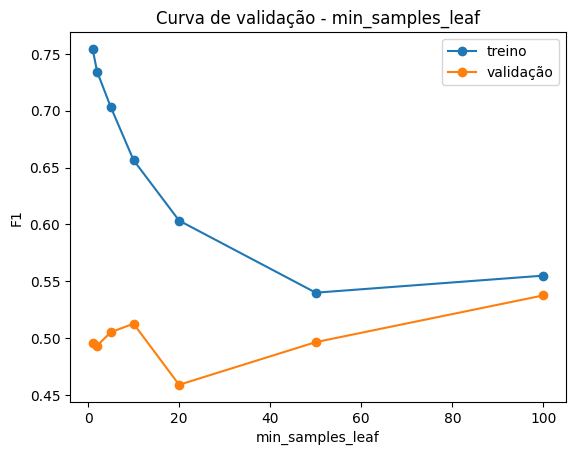

In [ ]:
min_leafs = [1, 2, 5, 10, 20, 50, 100]
f1_tr, f1_vl = [], []

for m in min_leafs:
    modelo = DecisionTreeClassifier(min_samples_leaf=m, max_depth=12, random_state=seed)
    modelo.fit(X_train, y_train_num)
    f1_tr.append(f1_score(y_train_num, modelo.predict(X_train)))
    f1_vl.append(f1_score(y_val, modelo.predict(X_val)))

plt.plot(min_leafs, f1_tr, marker='o', label='treino')
plt.plot(min_leafs, f1_vl, marker='o', label='validação')
plt.xlabel('min_samples_leaf'); plt.ylabel('F1'); plt.legend()
plt.title('Curva de validação - min_samples_leaf')
plt.show()

Aqui percebemos que aumentar o min_samples deixa a árvore mais simples.

Entre 1 e 5 gera overfitting.

Para valores próximos de 100 o treino caiu bastante, enquanto que a validação não mudou muita coisa.

O mais interessante seria algo entre 10 e 20, que é quando a curva de validação atinge o ponto mais alto.

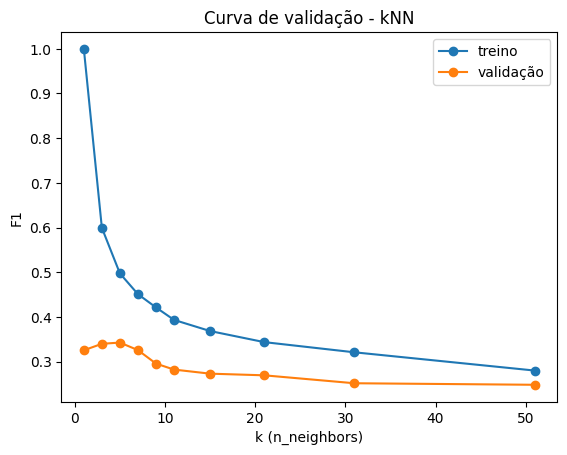

In [ ]:
ks = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]
f1_treino_knn, f1_valid_knn = [], []

for k in ks:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_train, y_train_num)
    f1_treino_knn.append(f1_score(y_train_num, modelo.predict(X_train)))
    f1_valid_knn.append(f1_score(y_val, modelo.predict(X_val)))

plt.plot(ks, f1_treino_knn, marker='o', label='treino')
plt.plot(ks, f1_valid_knn, marker='o', label='validação')
plt.xlabel('k (n_neighbors)'); plt.ylabel('F1'); plt.legend()
plt.title('Curva de validação - kNN')
plt.show()

k = 1 faz o modelo pegar outliers

Porém grande demais faz com que ele tenha problema na hora de identificar quem é quem.

Entre 3 e 7 aqui seria o ideal.

In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)

melhores_modelos = {}
resultados_busca = []

for model_name, modelo in modelos_busca.items():
    balanceamento_escolhido = melhor_balanceamento_por_modelo.loc[model_name]
    balanceador = metodos_balanceamento[balanceamento_escolhido]

    pipeline = ImbPipeline([
        ('balancer', balanceador),
        ('model', modelo)
    ])

    busca = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name],
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        verbose=3,
        refit=True
    )

    busca.fit(X_train, y_train_num)
    melhores_modelos[model_name] = busca.best_estimator_

    y_pred_val = busca.predict(X_val)

    resultados_busca.append({
        'modelo': model_name,
        'balanceamento': balanceamento_escolhido,
        'melhores_parametros': busca.best_params_,
        'f1_cv_treino': busca.best_score_,
        'f1_val': f1_score(y_val, y_pred_val),
        'acuracia_val': (y_pred_val == y_val).mean(),
        'balanced_accuracy_val': balanced_accuracy_score(y_val, y_pred_val)
    })

    print(f'--- {model_name} ---')
    print(f'Balanceamento usado: {balanceamento_escolhido}')
    print(f'Melhores hiperparâmetros: {busca.best_params_}')
    print(classification_report(y_val, y_pred_val, target_names=['no', 'yes']))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
--- knn ---
Balanceamento usado: none
Melhores hiperparâmetros: {'model__n_neighbors': 3, 'model__p': 2, 'model__weights': 'distance'}
              precision    recall  f1-score   support

          no       0.91      0.96      0.93      5988
         yes       0.45      0.27      0.34       794

    accuracy                           0.88      6782
   macro avg       0.68      0.62      0.64      6782
weighted avg       0.86      0.88      0.86      6782

Fitting 3 folds for each of 160 candidates, totalling 480 fits
--- decision_tree ---
Balanceamento usado: none
Melhores hiperparâmetros: {'model__criterion': 'entropy', 'model__max_depth': 8, 'model__min_samples_leaf': 10, 'model__min_samples_split': 10}
              precision    recall  f1-score   support

          no       0.93      0.97      0.95      5988
         yes       0.63      0.45      0.53       794

    accuracy                           0.91      6782
   m

/usr/local/lib/python3.13/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(


In [ ]:
df_busca = pd.DataFrame(resultados_busca)
df_busca

,modelo,balanceamento,melhores_parametros,f1_cv_treino,f1_val,acuracia_val,balanced_accuracy_val
0,knn,none,"{'model__n_neighbors': 3, 'model__p': 2, 'mode...",0.344893,0.342229,0.876438,0.615403
1,decision_tree,none,"{'model__criterion': 'entropy', 'model__max_de...",0.507605,0.526161,0.905190,0.707610
2,lvq,none,"{'model__alfa0': 0.1, 'model__epocas': 30, 'mo...",0.342972,0.307273,0.887644,0.594984


#Seção 5: Resultado e diagnóstico

###Seleção do modelo final

Com base nos resultados de validação da Seção 4 (f1_val), vamos escolher o modelo
com melhor desempenho para ser avaliado no conjunto de teste.

In [ ]:
resultados_teste = []

for nome, pipeline in melhores_modelos.items():
    y_pred = pipeline.predict(X_test)
    resultados_teste.append({
        'modelo': nome,
        'f1_teste': f1_score(y_test, y_pred),
        'balanced_accuracy_teste': balanced_accuracy_score(y_test, y_pred),
        'precision_teste': classification_report(y_test, y_pred, output_dict=True)['1']['precision'],
        'recall_teste': classification_report(y_test, y_pred, output_dict=True)['1']['recall']
    })

df_teste_final = pd.DataFrame(resultados_teste)
print(df_teste_final)

          modelo  f1_teste  balanced_accuracy_teste  precision_teste  \
0            knn  0.311688                 0.602578         0.395349   
1  decision_tree  0.525937                 0.710937         0.613445   
2            lvq  0.310254                 0.597325         0.508621   

   recall_teste  
0      0.257251  
1      0.460277  
2      0.223203  


/usr/local/lib/python3.13/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(


###Avaliação no conjunto de teste

Este é o único momento em que o conjunto de teste é utilizado, conforme definido na Seção 3.

--- Avaliação final: decision_tree ---

              precision    recall  f1-score   support

          no       0.93      0.96      0.95      5989
         yes       0.61      0.46      0.53       793

    accuracy                           0.90      6782
   macro avg       0.77      0.71      0.74      6782
weighted avg       0.89      0.90      0.90      6782

F1-score: 0.5259
Acurácia balanceada: 0.7109


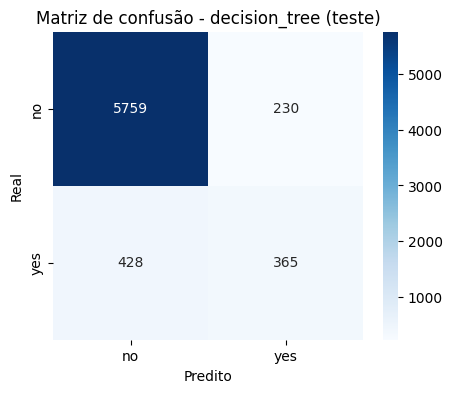

In [ ]:
y_test_final = y_test
melhor_modelo_nome = df_busca.loc[df_busca['f1_val'].idxmax(), 'modelo']
melhor_modelo = melhores_modelos[melhor_modelo_nome]

y_pred_test = melhor_modelo.predict(X_test)

#Exibindo as métricas
print(f'--- Avaliação final: {melhor_modelo_nome} ---\n')
print(classification_report(y_test_final, y_pred_test, target_names=['no', 'yes']))
print(f"F1-score: {f1_score(y_test_final, y_pred_test):.4f}")
print(f"Acurácia balanceada: {balanced_accuracy_score(y_test_final, y_pred_test):.4f}")

#Desenhando a Matriz de Confusão
cm = confusion_matrix(y_test_final, y_pred_test)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['no', 'yes'], yticklabels=['no', 'yes'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title(f'Matriz de confusão - {melhor_modelo_nome} (teste)')
plt.show()

###Diagnóstico: overfitting / underfitting

Comparamos o desempenho de cada modelo em treino (CV), validação e teste. Uma queda
grande do treino para a validação/teste indica overfitting; desempenho baixo em todos
os conjuntos indica underfitting.

/usr/local/lib/python3.13/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(


          modelo  f1_treino    f1_val  f1_teste
0            knn   1.000000  0.342229  0.311688
1  decision_tree   0.580915  0.526161  0.525937
2            lvq   0.338734  0.307273  0.310254


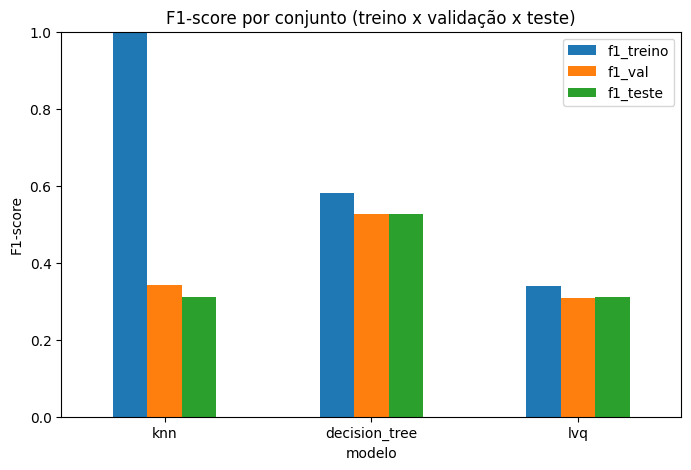

In [ ]:
diagnostico = []

for nome, pipeline in melhores_modelos.items():
    y_pred_train = pipeline.predict(X_train)
    y_pred_val_d = pipeline.predict(X_val)
    y_pred_test_d = pipeline.predict(X_test)

    diagnostico.append({
        'modelo': nome,
        'f1_treino': f1_score(y_train_num, y_pred_train),
        'f1_val': f1_score(y_val, y_pred_val_d),
        'f1_teste': f1_score(y_test, y_pred_test_d)
    })

df_diagnostico = pd.DataFrame(diagnostico)
print(df_diagnostico)

df_diagnostico.set_index('modelo').plot(kind='bar', figsize=(8, 5))
plt.title('F1-score por conjunto (treino x validação x teste)')
plt.ylabel('F1-score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

F1 no knn:
  Com resultado perfeito, devido ao peso por distância. Porém o overfitting é evidente devido a queda de valor do F1.

F1 no decision_tree:
  Aqui o resultado não foi bom, mas apresentou valores semelhantes no treino, validação e teste. Variância baixa.

F1 no lvq:
  Caso parecido do decision_tree, com diferença que agora é evidente o underfitting, pois apresentou desempenho muito baixo no treino.

          modelo balanceamento  \
1  decision_tree          none   
0            knn          none   
2            lvq          none   

                                 melhores_parametros  f1_cv_treino    f1_val  \
1  {'model__criterion': 'entropy', 'model__max_de...      0.507605  0.526161   
0  {'model__n_neighbors': 3, 'model__p': 2, 'mode...      0.344893  0.342229   
2  {'model__alfa0': 0.1, 'model__epocas': 30, 'mo...      0.342972  0.307273   

   f1_teste  balanced_accuracy_teste  precision_teste  recall_teste  
1  0.525937                 0.710937         0.613445      0.460277  
0  0.311688                 0.602578         0.395349      0.257251  
2  0.310254                 0.597325         0.508621      0.223203  


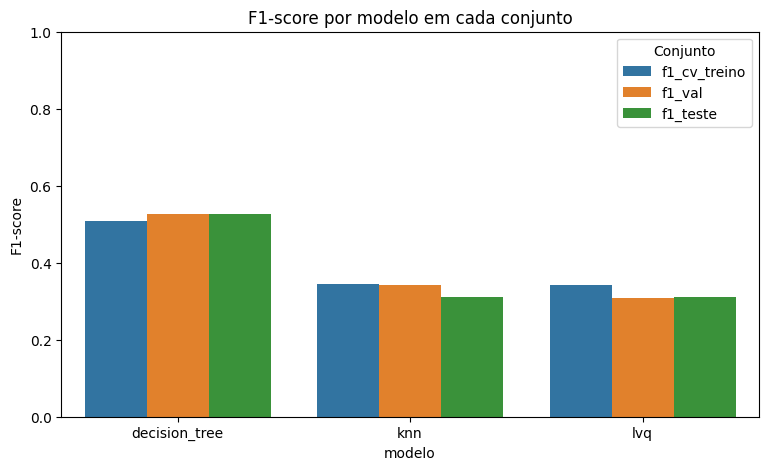

In [ ]:
comparacao_final = df_busca[['modelo', 'balanceamento', 'melhores_parametros', 'f1_cv_treino', 'f1_val']].merge(
    df_teste_final[['modelo', 'f1_teste', 'balanced_accuracy_teste', 'precision_teste', 'recall_teste']],
    on='modelo'
).sort_values('f1_teste', ascending=False)

print(comparacao_final)

df_plot = comparacao_final.melt(
    id_vars='modelo',
    value_vars=['f1_cv_treino', 'f1_val', 'f1_teste'],
    var_name='conjunto',
    value_name='f1'
)

plt.figure(figsize=(9, 5))
sns.barplot(data=df_plot, x='modelo', y='f1', hue='conjunto')
plt.title('F1-score por modelo em cada conjunto')
plt.ylim(0, 1)
plt.ylabel('F1-score')
plt.legend(title='Conjunto')
plt.show()

###Curvas ROC e Precisão-Revocação

Aplicável aos modelos que fornecem probabilidade (KNN e Árvore de Decisão). O LVQ,
por ser baseado em protótipos com predição por vizinho mais próximo, não gera
probabilidades e por isso não entra nessa comparação.

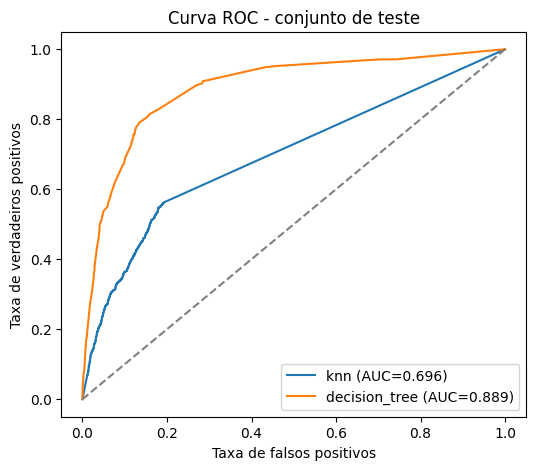

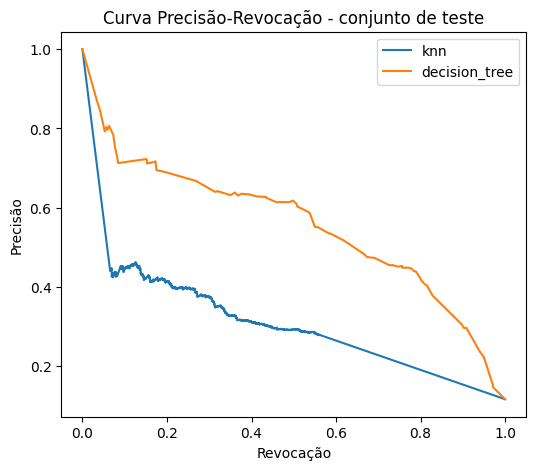

In [ ]:
plt.figure(figsize=(6, 5))
for nome, pipeline in melhores_modelos.items():
    if hasattr(pipeline, 'predict_proba'):
        proba = pipeline.predict_proba(X_test)[:, 1]


        fpr, tpr, _ = roc_curve(y_test, proba)
        plt.plot(fpr, tpr, label=f'{nome} (AUC={auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Taxa de falsos positivos')
plt.ylabel('Taxa de verdadeiros positivos')
plt.title('Curva ROC - conjunto de teste')
plt.legend()
plt.show()

plt.figure(figsize=(6, 5))
for nome, pipeline in melhores_modelos.items():
    if hasattr(pipeline, 'predict_proba'):
        proba = pipeline.predict_proba(X_test)[:, 1]

        precision, recall, _ = precision_recall_curve(y_test, proba)
        plt.plot(recall, precision, label=nome)

plt.xlabel('Revocação')
plt.ylabel('Precisão')
plt.title('Curva Precisão-Revocação - conjunto de teste')
plt.legend()
plt.show()

###Análise de erros

Vamos observar em que casos o modelo mais erra, comparando as características dos
clientes classificados incorretamente com as dos classificados corretamente.

In [ ]:
df_analise_erros = X_test.copy()
df_analise_erros['y_real'] = y_test.values
df_analise_erros['y_predito'] = y_pred_test
df_analise_erros['acertou'] = df_analise_erros['y_real'] == df_analise_erros['y_predito']

print(df_analise_erros.groupby(['y_real', 'y_predito']).size())

falsos_negativos = df_analise_erros[(df_analise_erros['y_real'] == 1) & (df_analise_erros['y_predito'] == 0)]
falsos_positivos = df_analise_erros[(df_analise_erros['y_real'] == 0) & (df_analise_erros['y_predito'] == 1)]

colunas_numericas = ['duration_log', 'balance_signed_log', 'age', 'campaign']

print('\nMédias - Falsos Negativos:')
print(falsos_negativos[colunas_numericas].mean())

print('\nMédias - Falsos Positivos:')
print(falsos_positivos[colunas_numericas].mean())

print('\nMédias - Classificados corretamente:')
print(df_analise_erros[df_analise_erros['acertou']][colunas_numericas].mean())

y_real  y_predito
0       0            5759
        1             230
1       0             428
        1             365
dtype: int64

Médias - Falsos Negativos:
duration_log           5.811120
balance_signed_log     5.398692
age                   42.205607
campaign               2.247664
dtype: float64

Médias - Falsos Positivos:
duration_log           6.294808
balance_signed_log     5.764109
age                   42.665217
campaign               1.991304
dtype: float64

Médias - Classificados corretamente:
duration_log           5.093966
balance_signed_log     4.770598
age                   41.116427
campaign               2.822665
dtype: float64


###Próximos Passos

1. Desconsiderar duration do pipeline de produção, já que o mesmo representa vazamento de dados

2. Avaliar melhor o desbalanceamento severo, tendo em vista que os modelos conseguiram um desempenho evidentemente superior com os dados desbalanceados. Então é importante avaliar combinações de balanceamento não exploradas.

3. Explorar os padrões encontrados na análise de erros.

#Seção 6: Declaração de uso de IA

Uso de IA para tirar dúvidas sobre a análise de gráficos, como os de relação das features com o target, métodos de preparação que poderiam ser melhores do que outros.

Na parte da correlação de Spearman, para avaliação e tomada de decisão.

Também na parte de treinamento e resultados para encontrar parâmetros e entendê-los melhor

Na parte para treinar e registrar os modelos, com assistência de IA para otimizar o LVQ e usar o numba

Sugestões de gráficos e como implementá-los no resultado e diagnóstico.

Nas partes finais do trabalho acabamos usando um pouco mais da IA devido ao tempo, mas foi apenas em algumas partes que só percebemos depois, como o gráfico do max_depth e min_samples da árvore e o k do knn.